In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import torchvision.models as models
import timm  # For EfficientNet
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Detect GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# === STEP 1: DATA LOADING === #

In [3]:
# Define dataset directories
data_dirs = {
    "Mild Demented": "ADNIAugmentedAlzheimerDataset/MildDemented/",
    "Moderate Demented": "ADNIAugmentedAlzheimerDataset/ModerateDemented/",
    "Non Demented": "ADNIAugmentedAlzheimerDataset/NonDemented/",
    "Very Mild Demented": "ADNIAugmentedAlzheimerDataset/VeryMildDemented/"
}

# Collect file paths and labels
filepaths, labels = [], []
for label, folder in data_dirs.items():
    if os.path.exists(folder):
        for file in os.listdir(folder):
            if file.endswith((".jpg", ".jpeg", ".png")):
                filepaths.append(os.path.join(folder, file))
                labels.append(label)

# Create DataFrame
df = pd.DataFrame({"filepaths": filepaths, "labels": labels})


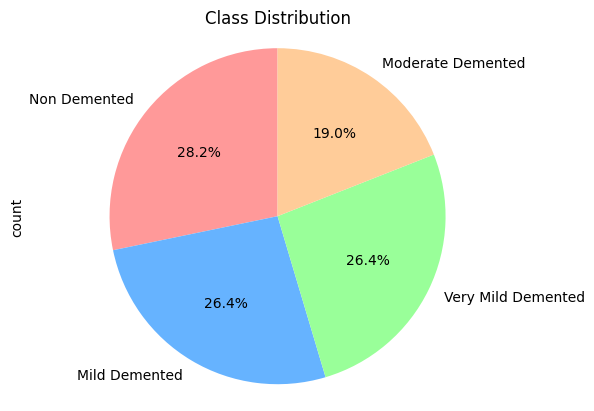

In [4]:
# Visualize class distribution
df["labels"].value_counts().plot(kind="pie", title="Class Distribution", autopct='%1.1f%%', startangle=90, colors=["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"])
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("Class Distribution")
plt.show()

# === STEP 2: Data Preprocessing === #

In [35]:
# Image preprocessing pipeline with augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Custom PyTorch Dataset
class MRI_Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.label_mapping = {"Non Demented": 0, "Very Mild Demented": 1, "Mild Demented": 2, "Moderate Demented": 3}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["filepaths"]
        label = self.label_mapping[self.df.iloc[idx]["labels"]]
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            return None, None

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


# === STEP 3: Split data: Train (64%), Validation (16%), Test (20%) === #

In [36]:
# Split data: Train (64%), Validation (16%), Test (20%)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["labels"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df["labels"], random_state=42)

# Weighted sampling for class imbalance
class_counts = train_df["labels"].value_counts()
class_weights = 1.0 / class_counts
sample_weights = train_df["labels"].map(class_weights).values
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# Create DataLoaders
train_loader = DataLoader(MRI_Dataset(train_df, transform), batch_size=32, sampler=sampler)
val_loader = DataLoader(MRI_Dataset(val_df, transform), batch_size=32, shuffle=False)
test_loader = DataLoader(MRI_Dataset(test_df, transform), batch_size=32, shuffle=False)

print (f"Train samples: {len(train_loader.dataset)}, Validation samples: {len(val_loader.dataset)}, Test samples: {len(test_loader.dataset)}")

#print train test validation data
print(f"Train Data Size: {len(train_df)}")
print(f"Validation Data Size: {len(val_df)}")
print(f"Test Data Size: {len(test_df)}")

#print labelwise train data
print("\nTrain Data Label Counts:")
print(train_df["labels"].value_counts())

#print labelwise validation data
print("\nValidation Data Label Counts:")
print(val_df["labels"].value_counts())

#print labelwise test data
print("\nTest Data Label Counts:")
print(test_df["labels"].value_counts())



Train samples: 21749, Validation samples: 5438, Test samples: 6797
Train Data Size: 21749
Validation Data Size: 5438
Test Data Size: 6797

Train Data Label Counts:
labels
Non Demented          6144
Very Mild Demented    5734
Mild Demented         5734
Moderate Demented     4137
Name: count, dtype: int64

Validation Data Label Counts:
labels
Non Demented          1536
Very Mild Demented    1434
Mild Demented         1434
Moderate Demented     1034
Name: count, dtype: int64

Test Data Label Counts:
labels
Non Demented          1920
Very Mild Demented    1792
Mild Demented         1792
Moderate Demented     1293
Name: count, dtype: int64


# === STEP 4: Train Model === #

In [41]:
def train_model(model, model_name, num_epochs, learning_rate=0.0001):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # Added label smoothing for stability
    scaler = torch.amp.GradScaler(enabled=device.type == 'cuda')  # Enabled based on device type

    # Track Loss & Accuracy
    train_losses, val_losses = [], []
    train_acc, val_acc = [], []

    best_val_loss = float('inf')  # For early stopping
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"{model_name} - Epoch {epoch+1}/{num_epochs}", leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(torch.int64).to(device)  # Converted labels to int64

            optimizer.zero_grad()  # Zero gradients before backpropagation
            
            with torch.amp.autocast(device_type=device.type, enabled=True):  # Device-aware autocast
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Mixed precision scaling
            scaler.scale(loss).backward()
            torch.cuda.synchronize()  # Ensures proper GPU synchronization
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_postfix(batch_loss=loss.item(), train_acc=100 * correct / total)

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)
        train_acc.append(train_accuracy)

        scheduler.step(train_loss)

        # Validation
        model.eval()
        correct = 0
        total = 0
        val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(torch.int64).to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_acc.append(100 * correct / total)

        # Trace progress
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_loss / len(val_loader):.4f} | Validation Accuracy: {100 * correct / total:.2f}%")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"{model_name}_best_model.pth")
        else:
            patience_counter += 1

        if patience_counter >= 2:
            print("Early stopping triggered!")
            break

    # Plot metrics after training
    plt.figure(figsize=(12, 5))
    plt.suptitle("Training and Validation Loss/Accuracy-Inceptionv3")
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(train_acc) + 1), train_acc, label="Train Accuracy")
    plt.plot(range(1, len(val_acc) + 1), val_acc, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

In [42]:
#define InceptionV3 model
model_name = "inception_v3"

Inception3 = timm.create_model(model_name, pretrained=True)
# Modify the classifier to match the number of classes
Inception3.fc = nn.Linear(Inception3.fc.in_features, 4)

In [43]:
from torchinfo import summary

Inception3.to(device)

# For inceptionNet-V3 (input size is typically 299*299)
summary(
    Inception3, 
    input_size=(1, 3, 224, 224),  # (batch_size, channels, H, W)
    col_names=["input_size", "output_size", "num_params"],
    col_width=25,
    row_settings=["var_names"]
)
# print(f"Model Architecture:\n{efficientnet_b3}\n")

Layer (type (var_name))                  Input Shape               Output Shape              Param #
InceptionV3 (InceptionV3)                [1, 3, 224, 224]          [1, 4]                    --
├─ConvNormAct (Conv2d_1a_3x3)            [1, 3, 224, 224]          [1, 32, 111, 111]         --
│    └─Conv2d (conv)                     [1, 3, 224, 224]          [1, 32, 111, 111]         864
│    └─BatchNormAct2d (bn)               [1, 32, 111, 111]         [1, 32, 111, 111]         64
│    │    └─Identity (drop)              [1, 32, 111, 111]         [1, 32, 111, 111]         --
│    │    └─ReLU (act)                   [1, 32, 111, 111]         [1, 32, 111, 111]         --
├─ConvNormAct (Conv2d_2a_3x3)            [1, 32, 111, 111]         [1, 32, 109, 109]         --
│    └─Conv2d (conv)                     [1, 32, 111, 111]         [1, 32, 109, 109]         9,216
│    └─BatchNormAct2d (bn)               [1, 32, 109, 109]         [1, 32, 109, 109]         64
│    │    └─Identity (drop)    

In [44]:
EPOCHS=1
train_model(Inception3, "Inception3", EPOCHS)
#save the model
torch.save(Inception3.state_dict(), "Inception3_bestmodel.pth")

Inception3 - Epoch 1/1:   0%|          | 0/680 [00:00<?, ?it/s]

KeyboardInterrupt: 

# === STEP 5: TEST Model === # 

In [ ]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_recall_fscore_support,
    classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
from torchvision import models
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

def test_model(model_name, test_loader, device):
    # Load model architecture and state_dict
    model = models.inception_v3(pretrained=False, aux_logits=False, transform_input=True)
    model.fc = nn.Linear(model.fc.in_features, 4)
    model.load_state_dict(torch.load("Inception3_bestmodel.pth", map_location=device))
    model.to(device)
    model.eval()

    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:",model_name)
    print(cm)

    # Metrics
    class_labels = ["Non-Demented", "VeryMildDemented", "MildDemented", "ModerateDemented"]
    acc = accuracy_score(y_true, y_pred) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=1)

    print(f"\n Results:", model_name)
    print(f"Accuracy: {acc:.2f}%")
    print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # ROC-AUC score
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
    roc_auc = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")*100
    print(f"ROC-AUC Score (macro): {roc_auc:.4f} %")

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix -" + model_name)
    plt.show()
    

    # Plot ROC Curves per class
    fpr = dict()
    tpr = dict()
    for i in range(4):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], np.array(y_probs)[:, i])
    
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(class_labels):
        plt.plot(fpr[i], tpr[i], label=f"{label} (AUC = {roc_auc_score(y_true_bin[:, i], np.array(y_probs)[:, i]):.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC Curves-" + model_name)
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

    return acc, precision, recall, f1, roc_auc

In [ ]:
# Test the model
test_model("Inception3",test_loader, device)
torch.save(Inception3.state_dict(), "Inception3_bestmodel.pth")

C:\Users\mahen\AppData\Local\Temp\ipykernel_24456\1155061150.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("InceptionNet-V3_best_mode


Confusion Matrix: inception_v3
[[1699  165   56    0]
 [ 118 1580   91    3]
 [   3   16 1771    2]
 [   0    0    0 1293]]

 Results: inception_v3
Accuracy: 93.32%
Precision: 0.93, Recall: 0.93, F1-Score: 0.93
                  precision    recall  f1-score   support

    Non-Demented       0.93      0.88      0.91      1920
VeryMildDemented       0.90      0.88      0.89      1792
    MildDemented       0.92      0.99      0.95      1792
ModerateDemented       1.00      1.00      1.00      1293

        accuracy                           0.93      6797
       macro avg       0.94      0.94      0.94      6797
    weighted avg       0.93      0.93      0.93      6797



IndexError: index 4 is out of bounds for axis 1 with size 4


# === STEP 6: Grad-CAM Implementation === #

In [30]:
import cv2
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.hook_layers()
    
    def hook_layers(self):
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
        
        def forward_hook(module, input, output):
            self.activations = output
        
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)
    
    def generate_heatmap(self, input_tensor, target_class=None):
        self.model.eval()
        input_tensor.requires_grad = True
        
        output = self.model(input_tensor)
        if target_class is None:
            target_class = torch.argmax(output, dim=1)
        
        self.model.zero_grad()
        class_score = output[:, target_class]
        class_score.backward(retain_graph=True)
        
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam

In [ ]:
models_dict = {
     "Inception3": (models.Inception3(pretrained=True), "features")
}
model_paths = {
    "InceptionNet_v3": "Inception3_bestmodel.pth"
}

c:\Users\mahen\Anaconda3\envs\ev3\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\mahen\Anaconda3\envs\ev3\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\mahen/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [01:17<00:00, 1.40MB/s] 


C:\Users\mahen\AppData\Local\Temp\ipykernel_24456\713683433.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("InceptionNet-V3_best_model

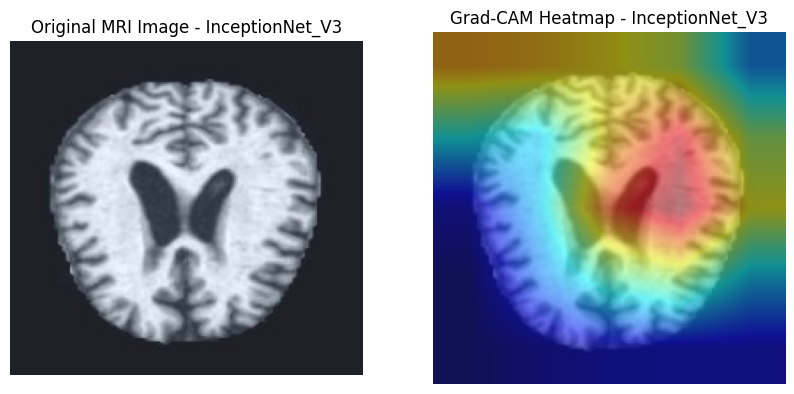

In [ ]:
import numpy as np
import cv2

device = "cuda" if torch.cuda.is_available() else "cpu"
performance_results = []

for model_name, (model, target_layer_name) in models_dict.items():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
   
    model = models.inception_v3(pretrained=False, aux_logits=False, transform_input=True)
    model.fc = nn.Linear(model.fc.in_features, 4)
    model.load_state_dict(torch.load("Inception3_bestmodel.pth", map_location=device))
    model.to(device)
    model.eval()
   
    # Use a valid layer name for timm's inception_v3, e.g., 'Mixed_7c'
    valid_target_layer_name = "Mixed_7c"
    target_layer = dict(model.named_modules())[valid_target_layer_name]
    grad_cam = GradCAM(model, target_layer)
    
    # Load Sample Image
    def preprocess_image(img_path):
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])
        image = Image.open(img_path).convert("RGB")
        return transform(image).unsqueeze(0)
   
    # Provide an MRI image path
    img_path = 'ADNIAugmentedAlzheimerDataset/ModerateDemented/003c36ee-8c43-41ce-b5e5-90622644bba5.jpg'  
    input_tensor = preprocess_image(img_path)
    input_tensor = input_tensor.to(device)
    
    # Generate Grad-CAM Heatmap
    heatmap = grad_cam.generate_heatmap(input_tensor)
    
    # Overlay Heatmap on Original Image
    def overlay_heatmap(img_path, heatmap):
        image = cv2.imread(img_path)
        image = cv2.resize(image, (224, 224))
        heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(image, 0.5, heatmap, 0.5, 0)
        return overlay
    
    overlay = overlay_heatmap(img_path, heatmap)
    
    # Display Results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.title(f"Original MRI Image - {model_name}")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM Heatmap - {model_name}")
    plt.axis("off")
    
    plt.show()
    

# === Model Performance Evaluation ===

Performance Result Summary for InceptionNet_V3
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1-Score: 1.00

Classification Report:
                   precision    recall  f1-score   support

     Non Demented       1.00      1.00      1.00         1
    Mild Demented       1.00      1.00      1.00         1
Moderate Demented       1.00      1.00      1.00         1

         accuracy                           1.00         3
        macro avg       1.00      1.00      1.00         3
     weighted avg       1.00      1.00      1.00         3


Confusion Matrix:
[[1 0 0]
 [0 1 0]
 [0 0 1]]


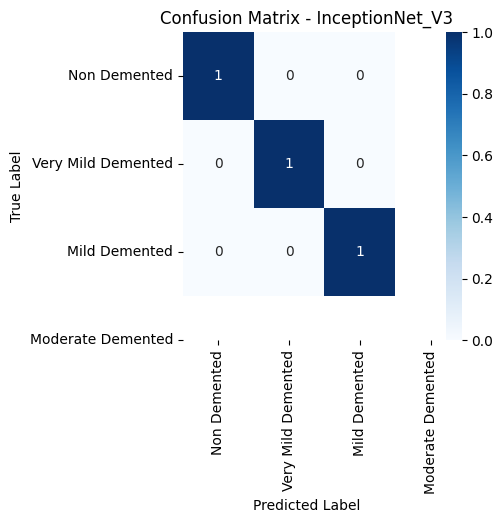

Performance results saved to InceptionNet_V3_performance.csv


In [35]:
y_true = []  # True labelss
y_pred = []  # Predicted labels
    
test_images = ['ADNIAugmentedAlzheimerDataset/ModerateDemented/0a5fa7ff-48fd-4578-98ba-de92d475e39b.jpg', 
                   'ADNIAugmentedAlzheimerDataset/MildDemented/0a2b4950-93a0-4854-a7d7-e73548c479c0.jpg', 
                   'ADNIAugmentedAlzheimerDataset/NonDemented/0a9c44e5-0029-46fc-96a9-7732572614bb.jpg']  
test_labels = [3, 2, 0]  
    
for img_path, label in zip(test_images, test_labels):
    input_tensor = preprocess_image(img_path).to(device)
    output = model(input_tensor)
    pred_label = torch.argmax(output, dim=1).cpu().numpy()[0]
    y_true.append(label)
    y_pred.append(pred_label)
    
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
performance_results.append([model_name, acc, precision, recall, f1])
   
print("Performance Result Summary for", model_name)
print("Accuracy: {:.2f}%".format(acc * 100))
print("Precision: {:.2f}".format(precision))
print("Recall: {:.2f}".format(recall))
print("F1-Score: {:.2f}".format(f1))
   
print("\nClassification Report:")
# Dynamically determine the target names based on the unique labels in y_true
unique_labels = sorted(set(y_true))
target_names = ["Non Demented", "Very Mild Demented", "Mild Demented", "Moderate Demented"]
filtered_target_names = [target_names[label] for label in unique_labels]
print(classification_report(y_true, y_pred, target_names=filtered_target_names))
   
print("\nConfusion Matrix:")
   
print(confusion_matrix(y_true, y_pred))
   
plt.figure(figsize=(4, 4))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix - {model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
   
# Save Grad-CAM results
cv2.imwrite(f"gradcam_{model_name}.jpg", overlay)
   
# Save performance results to CSV
performance_df = pd.DataFrame(performance_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
performance_df.to_csv(f"{model_name}_performance.csv", index=False)
print(f"Performance results saved to {model_name}_performance.csv")

# === Grad-CAM Visualization for Random Samples === #

C:\Users\mahen\AppData\Local\Temp\ipykernel_24456\1382726053.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("InceptionNet-V3_best_mode

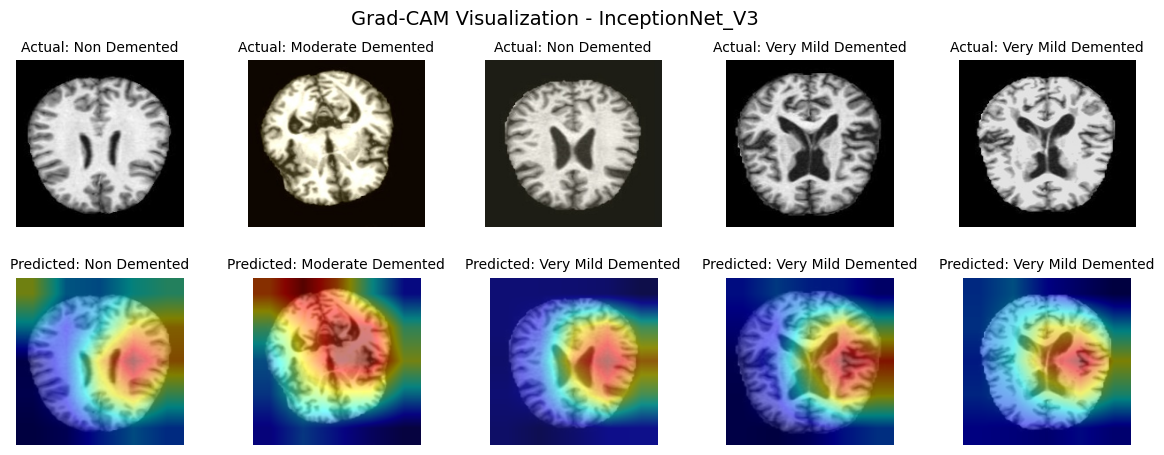

In [41]:
import numpy as np
import cv2
import matplotlib.gridspec as gridspec

def preprocess_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    image = Image.open(img_path).convert("RGB")
    return transform(image).unsqueeze(0)

def overlay_heatmap(img_path, heatmap):
    image = cv2.imread(img_path)
    image = cv2.resize(image, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(image, 0.5, heatmap, 0.5, 0)
    return overlay

def generate_gradcam(model, grad_cam, test_gc, model_name):
    sample_df = test_gc.sample(n=5).reset_index(drop=True)
    y_true = []
    y_pred = []
    
    # Display original images and Grad-CAM overlays
    class_labels = {0: "Non Demented", 1: "Very Mild Demented", 2: "Mild Demented", 3: "Moderate Demented"}
    
    plt.figure(figsize=(15, 5))
    gs = gridspec.GridSpec(2, 5)
    gs.update(wspace=0.1, hspace=0.3)  # Reduce horizontal and vertical space

    for i, row in sample_df.iterrows():
        img_path = row["filepaths"]
        true_label = row["labels"]
        true_label_str = class_labels[true_label]
        
        input_tensor = preprocess_image(img_path).to(device)
        output = model(input_tensor)
        pred_label = torch.argmax(output, dim=1).cpu().numpy()[0]
        pred_label_str = class_labels[pred_label]

        heatmap = grad_cam.generate_heatmap(input_tensor)
        overlay = overlay_heatmap(img_path, heatmap)

        # Original image on top row
        ax1 = plt.subplot(gs[0, i])
        ax1.imshow(Image.open(img_path))
        ax1.set_title(f"Actual: {true_label_str}", fontsize=10)
        ax1.axis("off")

        # Grad-CAM image on bottom row
        ax2 = plt.subplot(gs[1, i])
        ax2.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        ax2.set_title(f"Predicted: {pred_label_str}", fontsize=10)
        ax2.axis("off")

    plt.suptitle(f"Grad-CAM Visualization - {model_name}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leaves space for suptitle
    plt.show()

# Load test data
if test_df.empty:
    print("Warning: test_df is empty. Populating test_df with a subset of df for demonstration purposes.")
    test_gc = df.sample(n=10).reset_index(drop=True)  # Replace with actual test data loading logic
else:
    test_gc = test_df.copy() 
    test_gc["labels"] = test_df["labels"].map({"Non Demented": 0, "Very Mild Demented": 1, "Mild Demented": 2, "Moderate Demented": 3})

# Ensure the labels column is populated correctly
if test_gc["labels"].isnull().any():
    test_gc = df[df["filepaths"].isin(test_gc["filepaths"])].copy()


for model_name, (model, target_layer_name) in models_dict.items():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = timm.create_model('inception_v3', pretrained=False)  # Do NOT use pretrained=True here
    model.classifier = torch.nn.Linear(model.fc.in_features, 4)  # Ensure classifier matches training
    model.load_state_dict(torch.load("InceptionNet-V3_best_model.pth", map_location=device))  # Load weights properly
    model.to(device)
    model.eval()
    # Use a valid layer name for timm's inception_v3, e.g., 'Mixed_7c'
    valid_target_layer_name = "Mixed_7c"
    target_layer = dict(model.named_modules())[valid_target_layer_name]
    grad_cam = GradCAM(model, target_layer)
    
    
    generate_gradcam(model, grad_cam, test_gc, model_name)

# Save performance results to CSV
performance_df = pd.DataFrame(performance_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])


# === STEP 7: Test Pretrained Mode === #

In [ ]:
import random
import seaborn as sns
import matplotlib.pyplot as plt

# Load the trained model
model = models.inception_v3(pretrained=False, aux_logits=False, transform_input=True)
model.fc = nn.Linear(model.fc.in_features, 4)
model.load_state_dict(torch.load("Inception3_bestmodel.pth", map_location=device))
model.to(device)
model.eval()
# Use a valid layer name for timm's inception_v3, e.g., 'Mixed_7c'
valid_target_layer_name = "Mixed_7c"
target_layer = dict(model.named_modules())[valid_target_layer_name]
    
    

# Evaluate model
all_preds, all_labels = [], []
num_samples = 10
random_indices = random.sample(range(len(test_loader.dataset)), num_samples)

for images, labels in tqdm(test_loader, desc="Evaluating Model"):
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)
    
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())
    
    for i in range(images.shape[0]):
        if len(random_indices) > 0 and i in random_indices:
            heatmap, predicted_class = generate_gradcam(model, images[i].unsqueeze(0), target_layer)
            overlay_image = overlay_heatmap(test_loader.dataset.samples[i][0], heatmap)
            
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(images[i].permute(1, 2, 0).cpu().numpy())
            plt.title(f"Original (True: {labels[i].item()})")
            plt.axis("off")
            
            plt.subplot(1, 2, 2)
            plt.imshow(overlay_image)
            plt.title(f"Grad-CAM (Predicted: {predicted_class})")
            plt.axis("off")
            
            plt.show()
            random_indices.remove(i)



C:\Users\mahen\AppData\Local\Temp\ipykernel_24456\2066988326.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("InceptionNet-V3_best_model


Classification Report: InceptionNet_V3
                    precision    recall  f1-score   support

      Non Demented       0.93      0.88      0.91      1920
Very Mild Demented       0.90      0.88      0.89      1792
     Mild Demented       0.92      0.99      0.95      1792
 Moderate Demented       1.00      1.00      1.00      1293

          accuracy                           0.93      6797
         macro avg       0.94      0.94      0.94      6797
      weighted avg       0.93      0.93      0.93      6797


Accuracy Score:
1.0

Precision, Recall, F1-Score:
Precision: 0.93, Recall: 0.93, F1-Score: 0.93


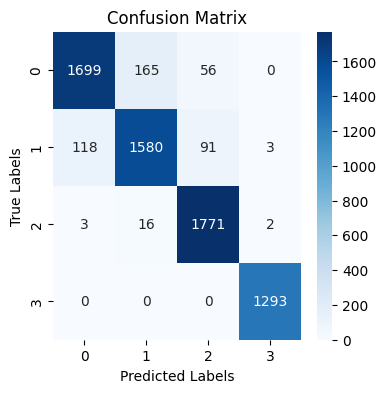

In [44]:
# Compute performance metrics
print("\nClassification Report:",model_name)
print(classification_report(all_labels, all_preds, target_names=["Non Demented", "Very Mild Demented", "Mild Demented", "Moderate Demented"]))
print("\nAccuracy Score:")
print(accuracy_score(y_true, y_pred))
print("\nPrecision, Recall, F1-Score:")
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(4), yticklabels=range(4))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
